In [182]:
# ! pip install pycirclize

In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pycirclize
from pycirclize import Circos
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import os

In [184]:
curr_dir = os.getcwd()
base_dir = os.path.dirname(curr_dir)
arena_data_dir = os.path.join(base_dir, '3D_Data')
arena_visualizations_dir = os.path.join( base_dir , '3D_Visualizations')

In [185]:
# CHANGE HERE: Path to your CSV file
all_df = pd.read_csv( os.path.join( arena_data_dir , 'combined_matrix_final_total136_lc.csv') , index_col=0 )

In [186]:
week1_df = all_df[(all_df['ExperimentType'] == 'week1')]
week3_df = all_df[(all_df['ExperimentType'] == 'week3')]
week6_df = all_df[(all_df['ExperimentType'] == 'week6')]

In [187]:
# Find clusters that are NOT in week 1
print("Clusters not present in Week 1:")
print(sorted(set(all_df['ClusterNumber'].unique().astype(int)) - set(week1_df['ClusterNumber'].unique().astype(int))))
print()

# Find clusters that are NOT in week 3
print("Clusters not present in Week 3:")
print(sorted(set(all_df['ClusterNumber'].unique().astype(int)) - set(week3_df['ClusterNumber'].unique().astype(int))))
print()

# Find clusters that are NOT in week 6
print("Clusters not present in Week 6:")
print(sorted(set(all_df['ClusterNumber'].unique().astype(int)) - set(week6_df['ClusterNumber'].unique().astype(int))))
print()

Clusters not present in Week 1:
[74, 75]

Clusters not present in Week 3:
[73]

Clusters not present in Week 6:
[73]



In [188]:
week1_df = week1_df.sort_values( by='ClusterNumber' , ascending=True )
week3_df = week3_df.sort_values( by='ClusterNumber' , ascending=True )
week6_df = week6_df.sort_values( by='ClusterNumber' , ascending=True )

In [189]:
def create_cluster_usage_df( df ):
    df = pd.DataFrame( df )

    df_cluster_usage = df['ClusterNumber'].value_counts().reset_index()
    df_cluster_usage.columns = ['ClusterNumber', 'count']
    df_cluster_usage['count'] = df_cluster_usage['count'].astype( int )
    total_count = df_cluster_usage['count'].sum()
    df_cluster_usage['percentage'] = df_cluster_usage['count'] / total_count * 100

    return df_cluster_usage

In [190]:
week1_cluster_usage = create_cluster_usage_df( week1_df )
week3_cluster_usage = create_cluster_usage_df( week3_df )
week6_cluster_usage = create_cluster_usage_df( week6_df )

In [191]:
week1_cluster_usage

,ClusterNumber,count,percentage
0,27.0,961,4.017726
1,21.0,869,3.633095
2,18.0,864,3.612191
3,30.0,794,3.319537
4,4.0,786,3.286091
...,...,...,...
68,73.0,49,0.204858
69,50.0,44,0.183954
70,70.0,42,0.175593
71,66.0,35,0.146327


In [192]:
# Week 1 to Week 3
def create_change_in__cluster_usage_week1toweek3( week1_cluster_usage , week3_cluster_usage ):
    merged_df = pd.merge( week1_cluster_usage , week3_cluster_usage , on='ClusterNumber' , how='right' , suffixes=('_week1' , '_week3'))
    merged_df['percentage_week1'] = merged_df['percentage_week1'].fillna(0)
    merged_df['change_in_usage'] = merged_df['percentage_week3'] - merged_df['percentage_week1']
    cluster_usage_change_week1toweek3= merged_df[['ClusterNumber', 'percentage_week1' , 'percentage_week3', 'change_in_usage']]
    return cluster_usage_change_week1toweek3

In [193]:
cluster_usage_change_week1toweek3= create_change_in__cluster_usage_week1toweek3( week1_cluster_usage , week3_cluster_usage )

In [194]:
cluster_usage_change_week1toweek3 = cluster_usage_change_week1toweek3.sort_values(by='ClusterNumber')

In [195]:
cluster_usage_change_week1toweek3 # Confirming values

,ClusterNumber,percentage_week1,percentage_week3,change_in_usage
72,1.0,1.818638,0.071073,-1.747565
58,2.0,2.174004,0.656382,-1.517622
67,3.0,1.174798,0.238304,-0.936494
53,4.0,3.286091,1.036833,-2.249258
38,5.0,2.161462,1.392199,-0.769263
...,...,...,...,...
37,70.0,0.175593,1.400560,1.224968
35,71.0,0.255027,1.429826,1.174798
60,72.0,0.660563,0.526778,-0.133785
32,74.0,0.000000,1.488357,1.488357


In [196]:
# Week 3 to Week 6
def create_change_in__cluster_usage_week3toweek6( week3_cluster_usage , week6_cluster_usage ):
    merged_df = pd.merge( week3_cluster_usage , week6_cluster_usage , on='ClusterNumber' , how='right' , suffixes=('_week3' , '_week6'))
    merged_df['percentage_week3'] = merged_df['percentage_week3'].fillna(0)
    merged_df['change_in_usage'] = merged_df['percentage_week6'] - merged_df['percentage_week3']
    cluster_usage_change_week3toweek6= merged_df[['ClusterNumber', 'percentage_week3' , 'percentage_week6', 'change_in_usage']]
    return cluster_usage_change_week3toweek6

In [197]:
cluster_usage_change_week3toweek6= create_change_in__cluster_usage_week3toweek6( week3_cluster_usage , week6_cluster_usage )

In [198]:
cluster_usage_change_week3toweek6 = cluster_usage_change_week3toweek6.sort_values(by='ClusterNumber')

In [199]:
cluster_usage_change_week3toweek6 # Confirming values

,ClusterNumber,percentage_week3,percentage_week6,change_in_usage
70,1.0,0.071073,0.083612,0.012539
50,2.0,0.656382,0.861204,0.204822
61,3.0,0.238304,0.317726,0.079421
23,4.0,1.036833,1.780936,0.744104
43,5.0,1.392199,1.120401,-0.271797
...,...,...,...,...
53,70.0,1.400560,0.668896,-0.731664
30,71.0,1.429826,1.517559,0.087733
68,72.0,0.526778,0.154682,-0.372096
22,74.0,1.488357,1.902174,0.413817


In [200]:
# Week 1 to Week 6
def create_change_in__cluster_usage_week1toweek6( week1_cluster_usage , week6_cluster_usage ):
    merged_df = pd.merge( week1_cluster_usage , week6_cluster_usage , on='ClusterNumber' , how='right' , suffixes=('_week1' , '_week6'))
    merged_df['percentage_week1'] = merged_df['percentage_week1'].fillna(0)
    merged_df['change_in_usage'] = merged_df['percentage_week6'] - merged_df['percentage_week1']
    cluster_usage_change_week1toweek6= merged_df[['ClusterNumber', 'percentage_week1' , 'percentage_week6', 'change_in_usage']]
    return cluster_usage_change_week1toweek6

In [201]:
cluster_usage_change_week1toweek6= create_change_in__cluster_usage_week1toweek6( week1_cluster_usage , week6_cluster_usage )

In [202]:
cluster_usage_change_week1toweek6 = cluster_usage_change_week1toweek6.sort_values(by='ClusterNumber')

In [203]:
cluster_usage_change_week1toweek6 # Confirming values

,ClusterNumber,percentage_week1,percentage_week6,change_in_usage
70,1.0,1.818638,0.083612,-1.735026
50,2.0,2.174004,0.861204,-1.312800
61,3.0,1.174798,0.317726,-0.857073
23,4.0,3.286091,1.780936,-1.505154
43,5.0,2.161462,1.120401,-1.041060
...,...,...,...,...
53,70.0,0.175593,0.668896,0.493304
30,71.0,0.255027,1.517559,1.262531
68,72.0,0.660563,0.154682,-0.505880
22,74.0,0.000000,1.902174,1.902174


In [204]:
# Graphs ALL transitions
def create_heatmaps_three_periods(df_week1to3, df_week3to6, df_week1to6, title, save=False, paths=None):
    # CHANGE HERE: Restrict ClusterNumber values based on what clusters appear across all 3 experiment types (week1, week3, week6)
    dfs = [df[(df['ClusterNumber'] >= 1) & (df['ClusterNumber'] <= 72)] for df in [df_week1to3, df_week3to6, df_week1to6]]

    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs]) # Get all change_in_usage values combined across all dfs

    # CHANGE HERE: Uncomment and comment based on which option you want
    # Option 1: Use color bar values based only on its own data. 
    # global_min = all_changes.min()
    # global_max = all_changes.max()

    # Option 2: Use color bar values based on another mouse. Ensures same scaling across different mice
    global_min = -4.774236665
    global_max = 4.531974437158014
    
    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    titles = [
        f"Change in Cluster Usage Percentage ({title} Week 1 to Week 3)",
        f"Change in Cluster Usage Percentage ({title} Week 3 to Week 6)",
        f"Change in Cluster Usage Percentage ({title} Week 1 to Week 6)"
    ]

    for i, filtered_df in enumerate(dfs):
        clusters = filtered_df['ClusterNumber'].astype(int).values
        change_values = filtered_df['change_in_usage'].values
    
        colors = plt.cm.bwr(norm(change_values))
    
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': 'polar'})
        theta = np.linspace(0, 2 * np.pi, len(clusters), endpoint=False)
        
        slice_width = 2 * np.pi / len(clusters)
        bar_width = slice_width * 0.9
        bars = ax.bar(theta, np.ones(len(clusters)), color=colors, width=bar_width, bottom=0.5)
    
        label_offset = 0
        theta_labels = (theta + label_offset) % (2 * np.pi)
    
        ax.set_xticks(theta_labels)
        ax.set_xticklabels(clusters, fontsize=5.5, rotation=45)

        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.tick_params(axis='x', pad=-8)
        ax.grid(False)
        ax.spines['polar'].set_visible(False)

        sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.1)
        cbar.set_label("Change in Usage Percentage")

        plt.title(titles[i])
        plt.tight_layout()

        if save:
            path = paths[i]
            eps_dir = os.path.dirname(path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)
            base_filename = os.path.splitext(os.path.basename(path))[0]
            eps_path = os.path.join(eps_dir, base_filename + '.eps')
            plt.savefig(eps_path, format='eps', bbox_inches='tight')
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, 'png')
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + '.png')
            plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
            print(f"PNG saved to: {png_path}")

        plt.show()


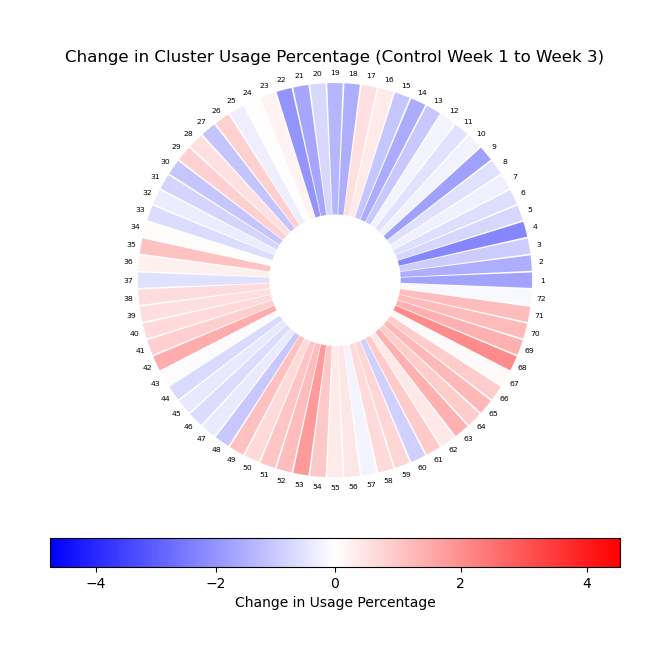

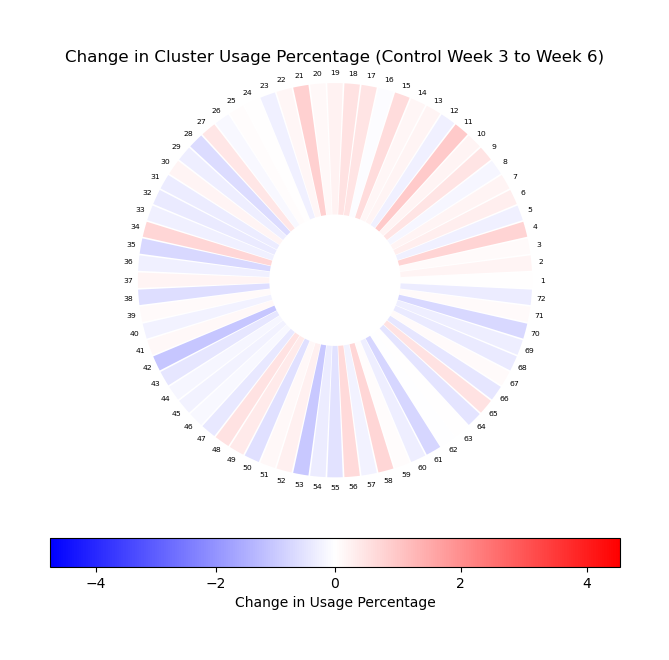

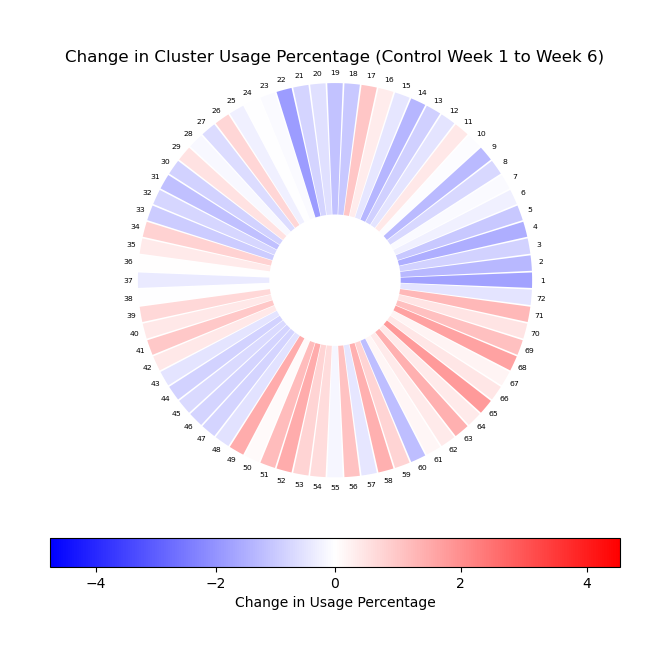

In [205]:
# CHANGE HERE: Path to your eps and png outputs
paths = [
    os.path.join(arena_visualizations_dir, 'Control/pie_charts/week1toweek3/eps/change_in_cluster_usage.eps'),
    os.path.join(arena_visualizations_dir, 'Control/pie_charts/week3toweek6/eps/change_in_cluster_usage.eps'),
    os.path.join(arena_visualizations_dir, 'Control/pie_charts/week1toweek6/eps/change_in_cluster_usage.eps')
]

# CHANGE HERE: Update title variable to match what title you want
create_heatmaps_three_periods(
    cluster_usage_change_week1toweek3,
    cluster_usage_change_week3toweek6,
    cluster_usage_change_week1toweek6,
    title="Control",
    save=False,
    paths=paths
)

In [206]:
# Graphs ALL transitions - Sorted
def create_heatmaps_three_periods(df_week1to3, df_week3to6, df_week1to6, title, save=False, paths=None):
    # CHANGE HERE: Restrict ClusterNumber values based on what clusters appear across all 3 experiment types (week1, week3, week6)
    dfs = [df[(df['ClusterNumber'] >= 1) & (df['ClusterNumber'] <= 72)] for df in [df_week1to3, df_week3to6, df_week1to6]]
    
    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs]) # Get all change_in_usage values combined across all dfs

    # CHANGE HERE: Uncomment and comment based on which option you want
    # Option 1: Use color bar values based only on its own data. 
    # global_min = all_changes.min()
    # global_max = all_changes.max()

    # Option 2: Use color bar values based on another mouse. Ensures same scaling across different mice
    global_min = -4.774236665
    global_max = 4.531974437158014

    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    titles = [
        f"Change in Cluster Usage Percentage ({title} Week 1 to Week 3)",
        f"Change in Cluster Usage Percentage ({title} Week 3 to Week 6)",
        f"Change in Cluster Usage Percentage ({title} Week 1 to Week 6)"
    ]

    for i, filtered_df in enumerate(dfs):
        filtered_df = filtered_df.sort_values( by='change_in_usage' , ascending=True )
        clusters = filtered_df['ClusterNumber'].astype(int).values
        change_values = filtered_df['change_in_usage'].values
    
        colors = plt.cm.bwr(norm(change_values))
    
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': 'polar'})
        theta = np.linspace(0, 2 * np.pi, len(clusters), endpoint=False)
        
        slice_width = 2 * np.pi / len(clusters)
        bar_width = slice_width * 0.9
        bars = ax.bar(theta, np.ones(len(clusters)), color=colors, width=bar_width, bottom=0.5)
    
        label_offset = 0
        theta_labels = (theta + label_offset) % (2 * np.pi)
    
        ax.set_xticks(theta_labels)
        ax.set_xticklabels(clusters, fontsize=5.5, rotation=45)

        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.tick_params(axis='x', pad=-8)
        ax.grid(False)
        ax.spines['polar'].set_visible(False)

        sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.1)
        cbar.set_label("Change in Usage Percentage")

        plt.title(titles[i])
        plt.tight_layout()

        if save:
            path = paths[i]
            eps_dir = os.path.dirname(path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)
            base_filename = os.path.splitext(os.path.basename(path))[0]
            eps_path = os.path.join(eps_dir, base_filename + '.eps')
            plt.savefig(eps_path, format='eps', bbox_inches='tight')
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, 'png')
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + '.png')
            plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
            print(f"PNG saved to: {png_path}")

        plt.show()


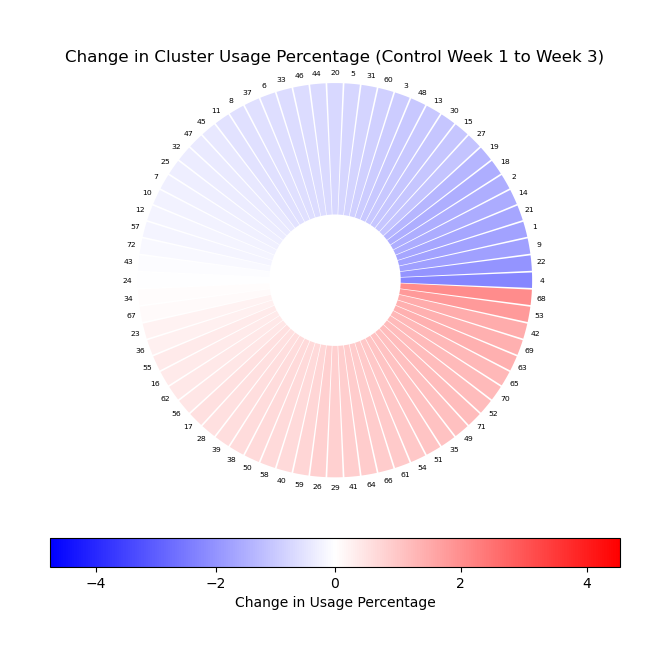

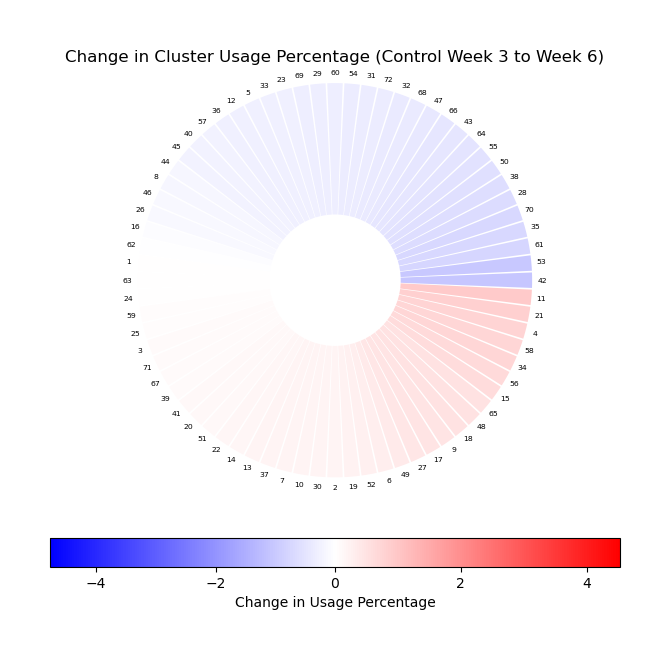

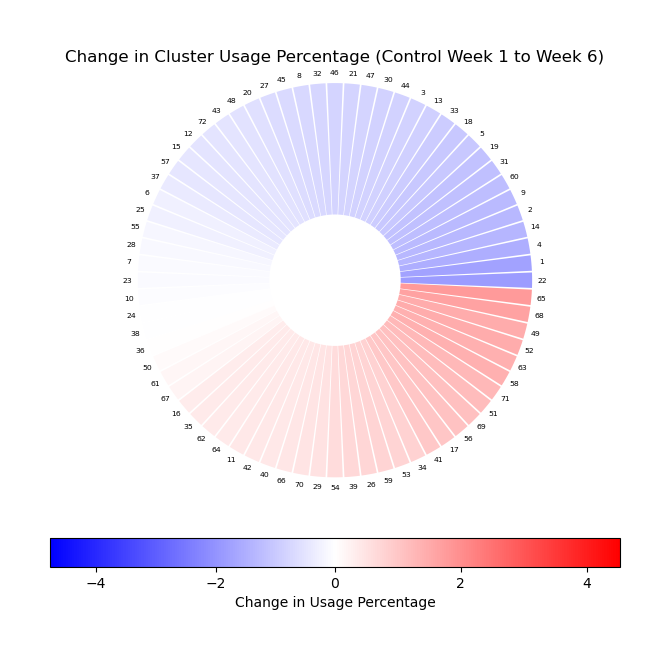

In [209]:
# CHANGE HERE: Path to your eps and png outputs
paths = [
    os.path.join(arena_visualizations_dir, 'Control/pie_charts_sorted/week1toweek3/eps/change_in_cluster_usage.eps'),
    os.path.join(arena_visualizations_dir, 'Control/pie_charts_sorted/week3toweek6/eps/change_in_cluster_usage.eps'),
    os.path.join(arena_visualizations_dir, 'Control/pie_charts_sorted/week1toweek6/eps/change_in_cluster_usage.eps')
]

# CHANGE HERE: Update title variable to match what title you want
create_heatmaps_three_periods(
    cluster_usage_change_week1toweek3,
    cluster_usage_change_week3toweek6,
    cluster_usage_change_week1toweek6,
    title="Control",
    save=False,
    paths=paths
)

In [208]:
# CHANGE HERE: Path to your CSV files
save_path = os.path.join( arena_visualizations_dir , 'Control\pie_charts\data\cluster_usage_change_week1toweek6.csv')
cluster_usage_change_week1toweek6.to_csv(save_path, index=False)

save_path = os.path.join( arena_visualizations_dir , 'Control\pie_charts\data\cluster_usage_change_week3toweek6.csv')
cluster_usage_change_week3toweek6.to_csv(save_path, index=False)

save_path = os.path.join( arena_visualizations_dir , 'Control\pie_charts\data\cluster_usage_change_week1toweek3.csv')
cluster_usage_change_week1toweek3.to_csv(save_path, index=False)